# Exploratory data analysis

5585 4212 1660
count    5.585000e+03
mean     5.529667e+06
std      1.231404e+07
min      1.000000e+04
25%      4.000000e+05
50%      1.000000e+06
75%      4.500000e+06
max      2.000000e+08
Name: current_value, dtype: float64


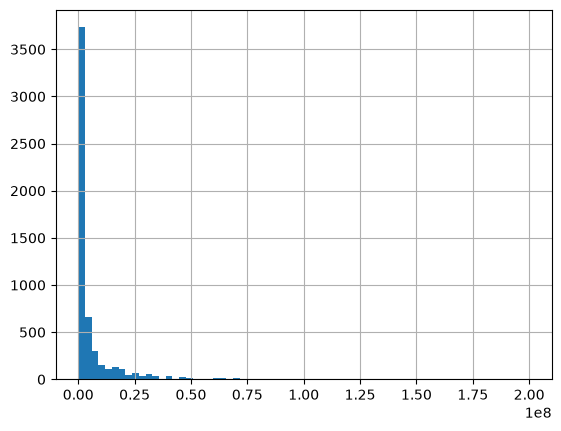

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
players_fresh_final = pd.read_csv('../data/players_fresh_final.csv')

players_fresh_final['current_value'].hist(bins=67)
print(len(players_fresh_final), len(players_fresh_final[players_fresh_final['current_value'] < 5000000]), len(players_fresh_final[players_fresh_final['current_value'] < 500000]))
print(players_fresh_final['current_value'].describe())

<Axes: >

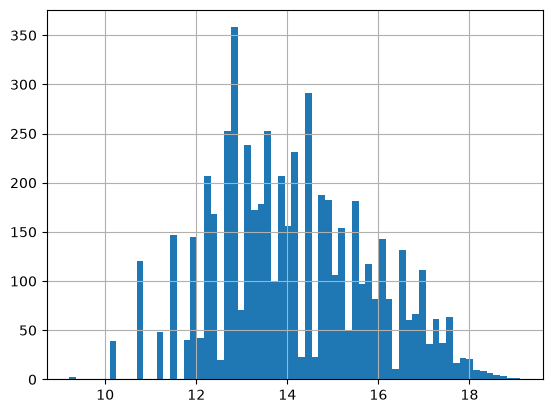

In [10]:
np.log1p(players_fresh_final['current_value']).hist(bins=67)

4212/5585(75.4%) of all players have market value lower than 5kk and 1660/5585(29.72%) have market value lower than 500k. Meanwhile the highest value is 200kk.
Raw distribution is skewed, log-transformed looks more normal - this justifies using log(value) as the model target later.

In [11]:
from scipy.stats import skew

print(f"Raw skewness: {skew(players_fresh_final['current_value']):.2f}")
print(f"Log skewness: {skew(np.log1p(players_fresh_final['current_value'])):.2f}")

Raw skewness: 5.12
Log skewness: 0.23


Skewness = 0 is ideal, so using Log is much better since it has only 0.23 skewness, compared to 5.12 of raw.

Text(0, 0.5, 'Log(Current Value)')

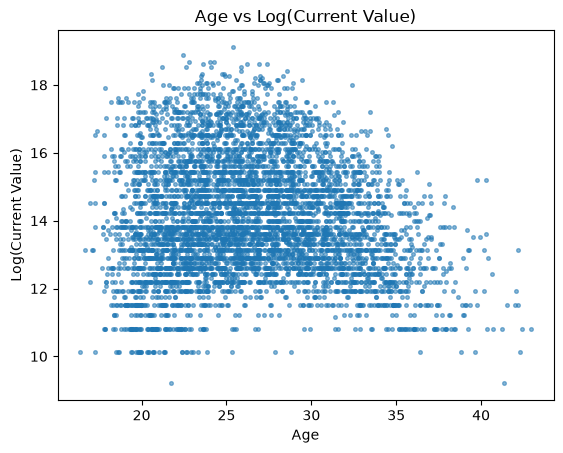

In [17]:
plt.scatter(players_fresh_final['age'], np.log1p(players_fresh_final['current_value']), alpha=0.52, s=7)
plt.title('Age vs Log(Current Value)')
plt.xlabel('Age')
plt.ylabel('Log(Current Value)')

Plot shows that value rises from the 19-20, peaks around 24-27 and declines after 30s. This matches age-value curve in football.

Note: horizontal lines in the scatter reflects Transfermarkt's use of discretevaluation (50k, 100k, 500k, 1M) rather than continuous pricing.

Text(0, 0.5, 'Goals per 90')

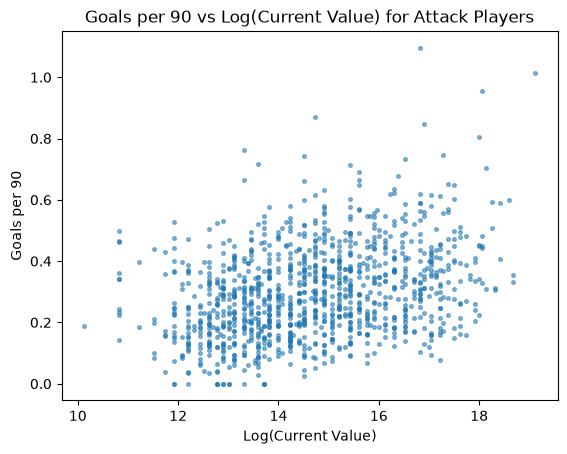

In [29]:
attack_players = players_fresh_final[players_fresh_final['position'] == 'Attack']
attack_players_filtered = attack_players[attack_players['total_minutes'] >= 900]
plt.scatter(np.log1p(attack_players_filtered['current_value']), attack_players_filtered['goals_per_90'], alpha=0.52, s=7)
plt.title('Goals per 90 vs Log(Current Value) for Attack Players')
plt.xlabel('Log(Current Value)')
plt.ylabel('Goals per 90')

In [30]:
print(attack_players[attack_players['goals_per_90'] > 20][['name', 'total_goals', 'total_minutes', 'goals_per_90']])

               name  total_goals  total_minutes  goals_per_90
2917  Jesper Uneken            1              2          45.0


Filtered to Attack players with >= 900 minutes played (same as in the SQL part).There is one player with 45 goals per 90 from just 2 minutes played.
The scatter shows a clear positive but noisy relationship between goals_per_90 and log(current_value), consistent with the expectation that scoring 
rate raises transfer value.

5059 3905


Text(0, 0.5, 'Assists per 90')

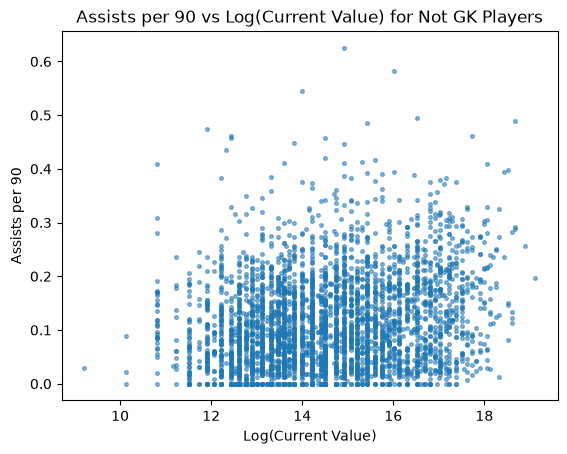

In [39]:
not_gk_players = players_fresh_final[players_fresh_final['position'].isin(['Attack', 'Midfield', 'Defender'])]
not_gk_players_filtered = not_gk_players[not_gk_players['total_minutes'] >= 900]
print(len(not_gk_players), len(not_gk_players_filtered))
plt.scatter(np.log1p(not_gk_players_filtered['current_value']), not_gk_players_filtered['assists_per_90'], alpha=0.52, s=7)
plt.title('Assists per 90 vs Log(Current Value) for Not GK Players')
plt.xlabel('Log(Current Value)')
plt.ylabel('Assists per 90')

The relationship between assists_per_90 and log(current_value) is positive but much weaker and noisier than goals_per_90.
Most players has less than 0.2-0.25 assists per 90 minutes, so assists don't correlate as much with trnasfer value

In [45]:
from scipy.stats import zscore
import seaborn as sns

players_fresh_final['z_score'] = zscore(np.log1p(players_fresh_final['current_value']))
outliers = players_fresh_final[players_fresh_final['z_score'].abs() > 3]
print(outliers[['name', 'current_value', 'position', 'age', 'z_score']])

print(players_fresh_final['z_score'].describe())
outliers = players_fresh_final[players_fresh_final['z_score'].abs() > 2.67]
print(outliers[['name', 'current_value', 'position', 'age', 'z_score']].sort_values(by='z_score', ascending=False))

Empty DataFrame
Columns: [name, current_value, position, age, z_score]
Index: []
count    5.585000e+03
mean     1.068677e-16
std      1.000090e+00
min     -2.866483e+00
25%     -7.078104e-01
50%     -1.715987e-01
75%      7.085857e-01
max      2.928972e+00
Name: z_score, dtype: float64
                  name  current_value  position        age   z_score
1298    Erling Haaland      200000000    Attack  25.385352  2.928972
2037   Jude Bellingham      160000000  Midfield  22.455852  2.798388
1229       Bukayo Saka      130000000    Attack  24.260096  2.676878
4384     Michael Olise      130000000    Attack  24.019165  2.676878
4376     Jamal Musiala      130000000  Midfield  22.811773  2.676878
4        Alaixys Romao          10000  Midfield  41.325120 -2.866483
3764  Maksym Radchenko          10000  Midfield  21.705681 -2.866483


No players have |z-score| > 3 on the log-transformed target, the highest z-score is 2.92. This confirms the log transform successfully normalized the distribution.
Even the most expensive players are not statistical outliers on a log scale, unlike on the raw current_value.

<Axes: >

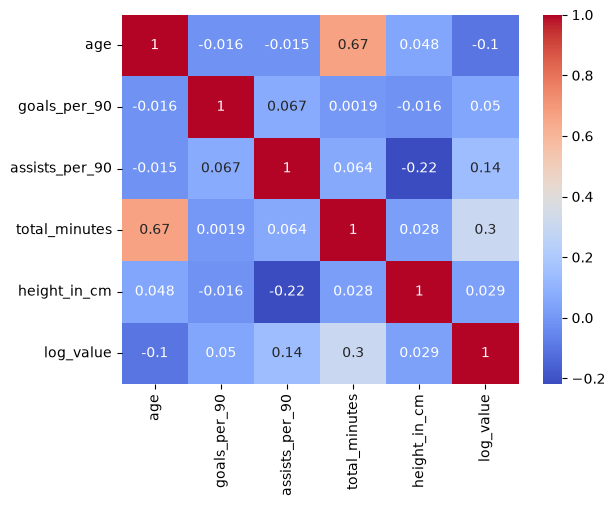

In [47]:
columns = ['age', 'goals_per_90', 'assists_per_90', 'total_minutes', 'height_in_cm', 'log_value']
corr = players_fresh_final[columns].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

There is no proper correlation between any of stats except total_minutes.
Total_minutes shows the strongest linear correlation with log_value (0.3), likely reflecting that career longevity signals top-level performance. 
Also age and total_minutes are correlated (0.67), worth keeping in mind during modeling.



<Axes: title={'center': 'log_value'}, xlabel='position'>

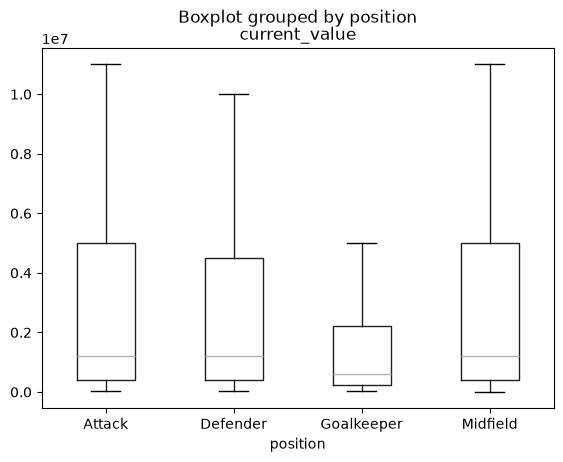

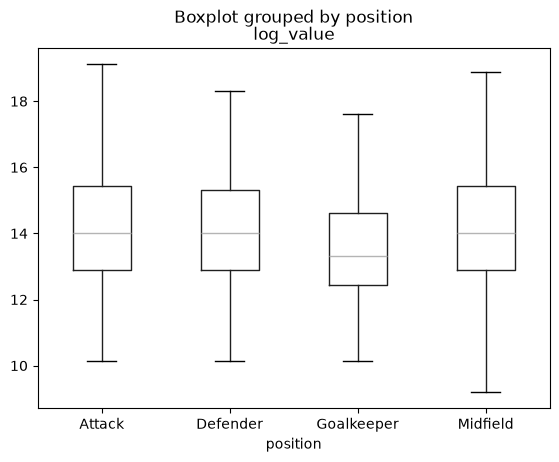

In [51]:
players_fresh_final.boxplot(column='current_value', by='position', grid=False, showfliers=False)
players_fresh_final.boxplot(column='log_value', by='position', grid=False, showfliers=False)

Goalkeepers show lower value distribution than other positions. It was expected. 
Attack, Defender, and Midfield are surprisingly similar in both median and spread. This suggests position alone is a 
weaker value driver and that individual performance metrics (goals/assists) likely matter more. This is worth revisiting once the model's feature importances are available.

count    5585.000000
mean       80.420949
std        31.579700
min        16.000000
25%        71.000000
50%        74.000000
75%        79.000000
max       329.000000
Name: days_since_update, dtype: float64


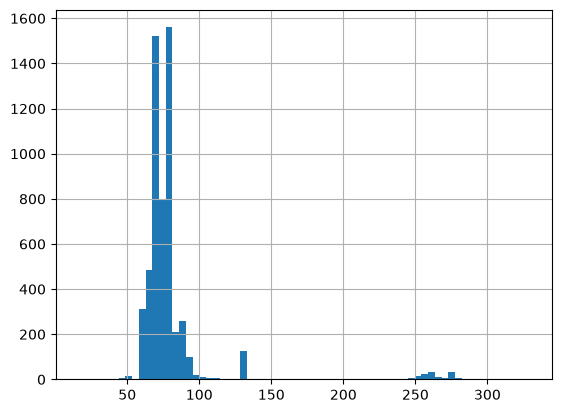

In [55]:
players_fresh_final['days_since_update'].hist(bins=67)
print(players_fresh_final['days_since_update'].describe())

Since we use only fresh players stats, all players were updated in last 300 days. 
There is a peek around 70-80 days (median 74) and empty gap between 150-240 days, and a small cluster around 250-280 days.
This suggests Transfermarkt updates valuations in batches rather than continuously per player, which is a property of the data source's update process, not random noise.

## Known confounders not captured in this dataset

Several factors that materially affect real market value are not present as 
features here and should be kept in mind when interpreting the model later:
- Contract situation (players entering the final year of a contract are typically valued lower regardless of performance)
- Injury history and current injury status
- Club's league position / promotion-relegation status
- Transfer market hype and agent-driven speculation, which can move valuations independent of on-pitch stats

This means any residual (actual vs. predicted value) should not automatically be read as "the model is right and the market is wrong" - some residuals will simply reflect these missing factors.